# Chapter 8 - Support Vector Machine (SVM) - Exercises

22302421 - Nguyễn Phúc Minh Châu

## Binary SVM Classification

Accuracy: 1.0


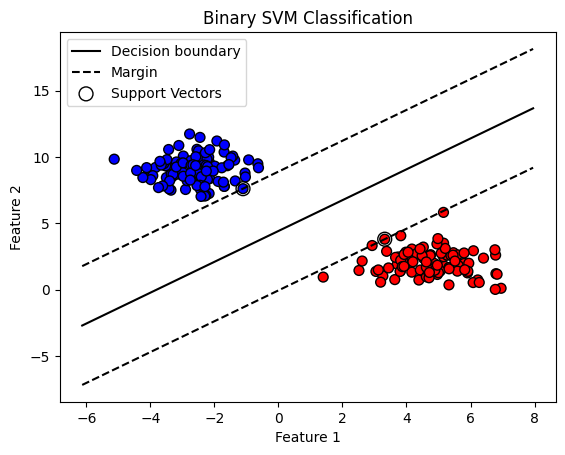

In [55]:
#Libraries Import
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Bước 1: Tạo 200 điểm dữ liệu giả lập nhị phân 2D
X, y = datasets.make_blobs(n_samples=200, centers=2, random_state=42)

# Chia dữ liệu thành tập huấn luyện và kiểm tra theo tỷ lệ (7:3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Bước 2: Tạo mô hình SVM tuyến tính & huấn luyện mô hình
model = SVC(kernel='linear', C=0.1)
model.fit(X_train, y_train)

# Bước 3: Dự đoán và đánh giá
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Bước 4: Vẽ dữ liệu và siêu phẳng phân lớp
def plot_svm(X, y, model):
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=50, edgecolors='k')

    # Lấy trọng số và bias
    w = model.coef_[0]
    b = model.intercept_[0]

    # Vẽ siêu phẳng: w0*x + w1*y + b = 0 -> y = -(w0*x + b)/w1
    x_plot = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
    y_plot = -(w[0]*x_plot + b)/w[1]
    plt.plot(x_plot, y_plot, 'k-', label='Decision boundary')

    # Vẽ margin
    margin = 1/np.linalg.norm(w)
    y_margin_up = y_plot + np.sqrt(1 + (w[0]/w[1])**2)*margin
    y_margin_down = y_plot - np.sqrt(1 + (w[0]/w[1])**2)*margin
    plt.plot(x_plot, y_margin_up, 'k--', label='Margin')
    plt.plot(x_plot, y_margin_down, 'k--')

    # Vẽ support vectors
    plt.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1], s=100,
                facecolors='none', edgecolors='k', label='Support Vectors')

    plt.legend()
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Binary SVM Classification')
    plt.show()

plot_svm(X, y, model)

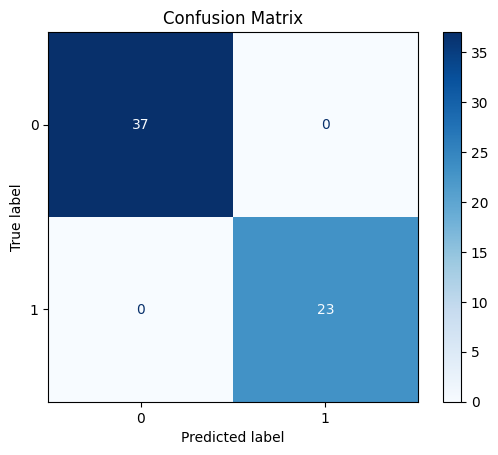

In [9]:
# Vẽ confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [10]:
# In classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        23

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [11]:
# Tạo 20 điểm dữ liệu nhị phân 2D ngẫu nhiên
X_new, y_new = datasets.make_blobs(n_samples=20, centers=2, random_state=100, cluster_std=1.0)
print("Generated new 2D binary data points (X_new):")
print(X_new)
print("Corresponding labels (y_new):")
print(y_new)

Generated new 2D binary data points (X_new):
[[ 0.6162197  -5.27504804]
 [-0.77864784  8.25707877]
 [-0.75920342  6.43957572]
 [-0.32002592  5.20490582]
 [ 2.4870805  -2.89100712]
 [ 0.28450379 -3.61576523]
 [ 1.54081964 -4.53702344]
 [ 0.41007185 -3.99744881]
 [ 0.678603   -4.17761085]
 [ 0.42996321 -5.55093054]
 [ 1.84941962 -3.91839346]
 [-2.86604723  5.66308813]
 [-2.26600049  7.71197666]
 [ 0.33681846 -3.40287961]
 [-1.50233362  6.28258391]
 [ 1.08927851 -5.50265563]
 [-1.83588624  6.95119866]
 [-1.28724858  5.45230565]
 [-2.05408735  6.22735091]
 [-1.32512949  7.83260485]]
Corresponding labels (y_new):
[0 1 1 1 0 0 0 0 0 0 0 1 1 0 1 0 1 1 1 1]


In [12]:
# Phân loại 20 điểm dữ liệu trên
y_new_pred = model.predict(X_new)
print("Predicted labels for new data points (y_new_pred):")
print(y_new_pred)

Predicted labels for new data points (y_new_pred):
[1 0 0 0 1 1 1 1 1 1 1 0 0 1 0 1 0 0 0 0]


In [14]:
# Cho biết công thức của hàm phân loại
w = model.coef_[0]
b = model.intercept_[0]
print(f"Công thức hàm phân loại (decision function): f(x) = {w[0]:.4f} * x_0 + {w[1]:.4f} * x_1 + {b:.4f}")

Công thức hàm phân loại (decision function): f(x) = 0.2597 * x_0 + -0.2234 * x_1 + 0.9879


In [15]:
# In giá trị của hàm phân loại khi áp dụng cho 20 điểm dữ liệu trên
decision_values = model.decision_function(X_new)
print("Giá trị của hàm phân loại cho 20 điểm dữ liệu mới:")
print(decision_values)

Giá trị của hàm phân loại cho 20 điểm dữ liệu mới:
[ 2.32640769 -1.05890515 -0.64782238 -0.25795194  2.27962202  1.86958289
  2.40162599  1.98745845  2.09743749  2.33967443  2.34355823 -1.02144572
 -1.32335481  1.8356086  -0.80572155  2.50009662 -1.0417062  -0.56438389
 -0.93665837 -1.10598384]


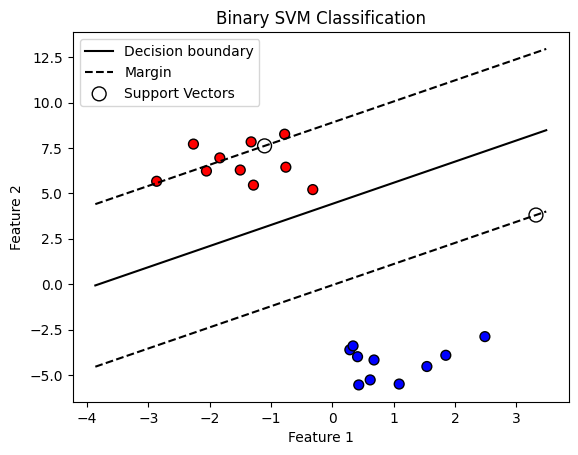

In [16]:
# Vẽ 20 điểm dữ liệu trên và siêu phẳng phân lớp
plot_svm(X_new, y_new, model)

## Multi-class SVM Classification
While the original SVM is binary, scikit-learn automatically extends it to multi-class using One-vs-Rest (OvR) or One-vs-One (OvO):

Accuracy: 1.0


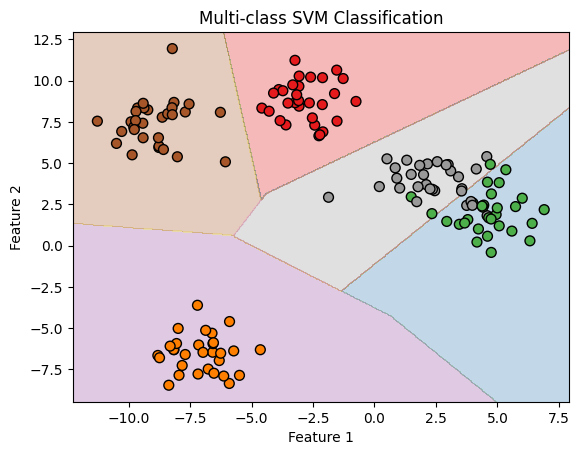

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Bước 1: Tạo dữ liệu 5 lớp (5 centers)
X, y = datasets.make_blobs(n_samples=150, centers=5, cluster_std=1.2, random_state=42)

# Chia dữ liệu thành tập huấn luyện và kiểm tra theo tỷ lện (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bước 2: Tạo mô hình SVM tuyến tính & huấn luyện mô hình
model = SVC(kernel='linear', C=1.0)
model.fit(X_train, y_train)

# Bước 3: Dự đoán và đánh giá
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Bước 4: Vẽ dữ liệu và siêu phẳng phân lớp (chỉ minh họa trên 2D)
def plot_svm_multi(X, y, model):
    # Tạo lưới để dự đoán
    x_min, x_max = X[:, 0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Vẽ vùng phân lớp
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
    plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='Set1', edgecolors='k')
    plt.title('Multi-class SVM Classification')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

plot_svm_multi(X, y, model)

## Nonlinear binary SVM classification

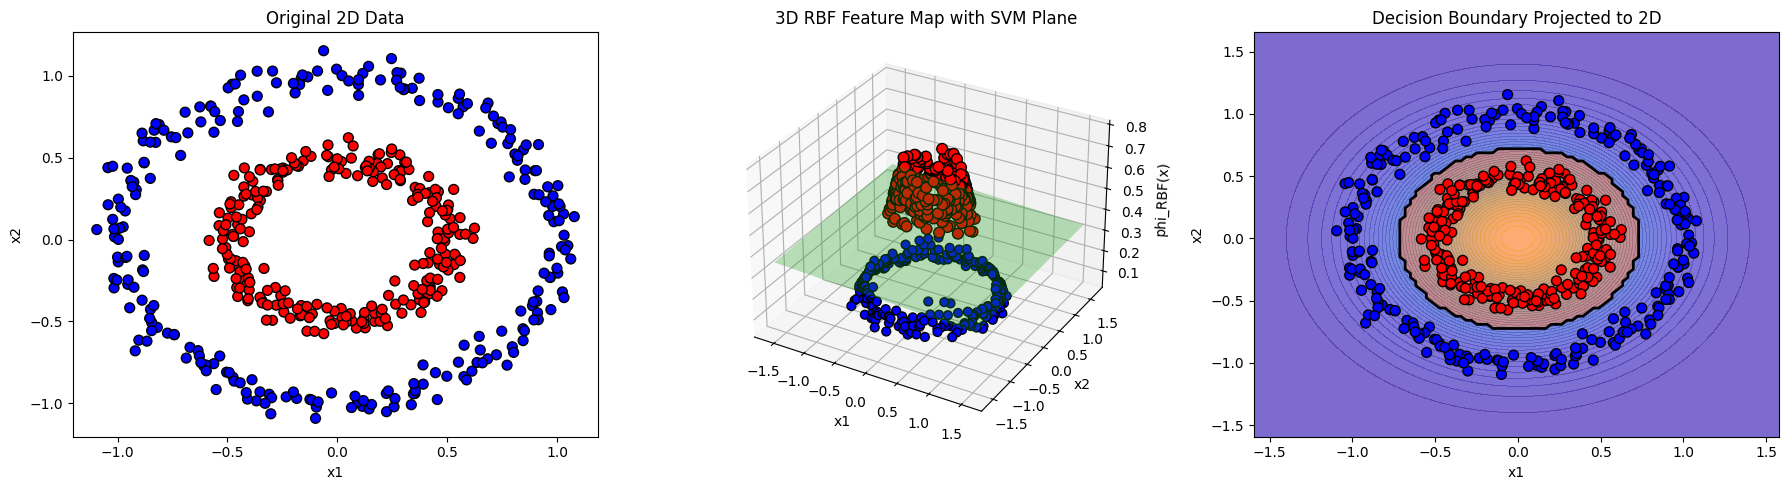

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_circles
from mpl_toolkits.mplot3d import Axes3D

# Tạo 500 điểm dữ liệu phi tuyến dạng hai hình tròn
X,y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Hàm ánh xạ RBF sang không gian 3D
def rbf_feature_map(X, gamma=2.0):
    r = np.sum(X**2, axis=1)
    Z = np.exp(-gamma * r)
    return Z

gamma = 2.0
Z = rbf_feature_map(X, gamma)
X3 = np.column_stack([X, Z])

# Huấn luyện SVM tuyến tính trong không gian 3D
clf3d = svm.SVC(kernel='linear')
clf3d.fit(X3, y)

# Lấy tham số siêu phẳng w^T.x + b
w = clf3d.coef_[0]
b = clf3d.intercept_[0]

# Lưới mặt phẳng
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 100)
)
zz = -(w[0] * xx + w[1] * yy + b) / w[2]

# Xác định điểm trên/dưới siêu phẳng
plane_z = -(w[0]*X[:,0] + w[1]*X[:,1] + b)/w[2]
below_mask = Z < plane_z
above_mask = Z >= plane_z

# Đảm bảo dữ liệu nằm trên thực sự nằm trên siêu phẳng
epsilon = 0.05  # khoảng cách nhỏ
Z_above = np.maximum(Z, plane_z + epsilon)
Z_below = np.minimum(Z, plane_z - epsilon)

# Tạo figure với 3 subplots
fig = plt.figure(figsize=(18,5))

# Hình 1: dữ liệu gốc 2D
ax1 = fig.add_subplot(131)
ax1.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k', s=50)
ax1.set_title("Original 2D Data")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")

# Hình 2: dữ liệu RBF 3D với siêu phẳng
ax2 = fig.add_subplot(132, projection='3d')

# 1. Dữ liệu dưới siêu phẳng
ax2.scatter(X[below_mask,0], X[below_mask,1], Z_below[below_mask],
            color='blue', edgecolor='k', s=40, alpha=1.0)

# 2. Siêu phẳng
ax2.plot_surface(xx, yy, zz, color=(0.1,0.8,0.1), alpha=0.3, rstride=1, cstride=1, linewidth=0, antialiased=True)

# 3. Dữ liệu trên siêu phẳng
ax2.scatter(X[above_mask,0], X[above_mask,1], Z_above[above_mask],
            color='red', edgecolor='k', s=60, alpha=1.0)

ax2.set_title("3D RBF Feature Map with SVM Plane")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_zlabel("phi_RBF(x)")

# Hình 3: chiếu 2D với gradient phi_RBF + dự đoán lớp
ax3 = fig.add_subplot(133)

# Tạo grid 2D cho dự đoán
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z_grid = np.exp(-gamma * np.sum(grid_points**2, axis=1))
X_grid3 = np.column_stack([grid_points, Z_grid])
pred_grid = clf3d.predict(X_grid3).reshape(xx.shape)

# Gradient phi_RBF
Z_surface = np.exp(-gamma * (xx**2 + yy**2))
ax3.contourf(xx, yy, Z_surface, levels=50, cmap='viridis', alpha=0.4)

# Vùng dự đoán lớp phi tuyến
ax3.contourf(xx, yy, pred_grid, levels=[-0.1,0.5,1.1], colors=['blue','red'], alpha=0.3)

# Contour đen ranh giới
ax3.contour(xx, yy, pred_grid, levels=[0.5], colors='k', linewidths=2)

# Vẽ điểm dữ liệu
ax3.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k', s=50)

ax3.set_title("Decision Boundary Projected to 2D")
ax3.set_xlabel("x1")
ax3.set_ylabel("x2")

plt.tight_layout()
plt.show()

## Create interactive charts with plotly

In [1]:
# Cài đặt thư viện nếu chưa cài
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import plotly.graph_objects as go
from sklearn import svm
from sklearn.datasets import make_circles

# -------------------------------
# 1. Tạo 500 điểm dữ liệu phi tuyến dạng hai vòng tròn
# -------------------------------
X,y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Hàm ánh xạ RBF sang 3D
def rbf_feature_map(X, gamma=2.0):
    r = np.sum(X**2, axis=1)
    return np.exp(-gamma * r)

gamma = 2.0
Z = rbf_feature_map(X, gamma)
X3 = np.column_stack([X, Z])

# Huấn luyện SVM tuyến tính trong không gian 3D
clf3d = svm.SVC(kernel='linear')
clf3d.fit(X3, y)

# Lấy tham số siêu phẳng w^T.x + b
w = clf3d.coef_[0]
b = clf3d.intercept_[0]

# -------------------------------
# 2. Lưới siêu phẳng
# -------------------------------
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 80),
    np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 80)
)
zz = -(w[0]*xx + w[1]*yy + b)/w[2]

# Xác định điểm trên/dưới siêu phẳng
plane_z = -(w[0]*X[:,0] + w[1]*X[:,1] + b)/w[2]
below_mask = Z < plane_z
above_mask = Z >= plane_z

# Đảm bảo dữ liệu trên thật sự cao hơn surface
epsilon = 0.5
Z_above = np.maximum(Z, plane_z + epsilon)
Z_below = np.minimum(Z, plane_z - 0.1)

# -------------------------------
# 3. Scatter 3D + Surface đẹp mắt
# -------------------------------
trace_below = go.Scatter3d(
    x=X[below_mask,0], y=X[below_mask,1], z=Z_below[below_mask],
    mode='markers',
    marker=dict(size=5, color='blue', opacity=0.8),
    name='Below Plane'
)

trace_above = go.Scatter3d(
    x=X[above_mask,0], y=X[above_mask,1], z=Z_above[above_mask],
    mode='markers',
    marker=dict(size=6, color='red', opacity=0.9),
    name='Above Plane'
)

trace_surface = go.Surface(
    x=xx, y=yy, z=zz,
    colorscale=[[0,'green'],[1,'green']],
    opacity=0.35,
    name='SVM Plane',
    showscale=False
)

fig3d = go.Figure(data=[trace_surface, trace_below, trace_above])

# Tùy chỉnh layout đẹp mắt
fig3d.update_layout(
    title="3D RBF Feature Map with SVM Plane (Interactive)",
    scene=dict(
        xaxis=dict(title='x1', range=[-2, 2], backgroundcolor="rgb(240,240,240)"),
        yaxis=dict(title='x2', range=[-2, 2], backgroundcolor="rgb(240,240,240)"),
        zaxis=dict(title='phi_RBF(x)', range=[-0.2, 2], backgroundcolor="rgb(240,240,240)"),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)),
        aspectratio=dict(x=1, y=1, z=0.8)
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)
fig3d.show()

# -------------------------------
# 4. Chiếu 2D với gradient phi_RBF + ranh giới
# -------------------------------
Z_surface2D = np.exp(-gamma * (xx**2 + yy**2))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z_grid = np.exp(-gamma * np.sum(grid_points**2, axis=1))
X_grid3 = np.column_stack([grid_points, Z_grid])
pred_grid = clf3d.predict(X_grid3).reshape(xx.shape)

fig2d = go.Figure()

# Gradient phi_RBF
fig2d.add_trace(go.Contour(
    z=Z_surface2D,
    x=xx[0,:], y=yy[:,0],
    colorscale='Viridis',
    opacity=0.4,
    showscale=False,
    name='phi_RBF Gradient'
))

# Vùng dự đoán lớp
fig2d.add_trace(go.Contour(
    z=pred_grid,
    x=xx[0,:], y=yy[:,0],
    colorscale=[[0,'blue'],[1,'red']],
    opacity=0.3,
    showscale=False,
    contours=dict(start=0,end=1,size=1),
    name='Predicted Class'
))

# Ranh giới contour
fig2d.add_trace(go.Contour(
    z=pred_grid,
    x=xx[0,:], y=yy[:,0],
    contours=dict(start=0.5,end=0.5),
    line=dict(color='black', width=2),
    showscale=False,
    name='Decision Boundary'
))

# Điểm dữ liệu
fig2d.add_trace(go.Scatter(
    x=X[:,0], y=X[:,1], mode='markers',
    marker=dict(color=['red' if label==1 else 'blue' for label in y],
                line=dict(color='black', width=1), size=6),
    name='Data Points'
))

fig2d.update_layout(
    title="Decision Boundary Projected to 2D",
    xaxis_title='x1', yaxis_title='x2',
    width=700, height=700,
    margin=dict(l=50, r=50, t=50, b=50)
)
fig2d.show()

## Iris flower classification using SVM

Accuracy: 0.8333333333333334


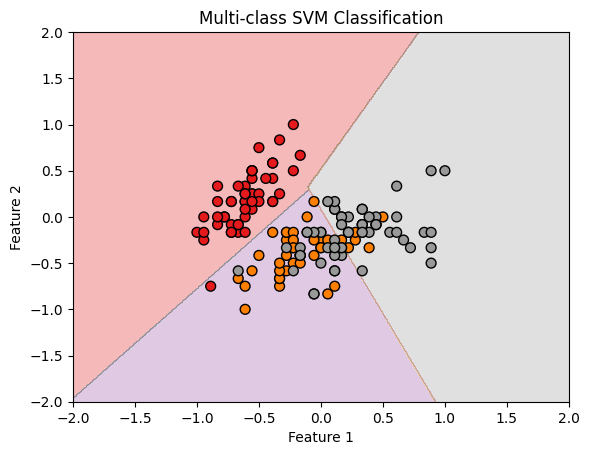

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

# Bước 1: Load dữ liệu hoa iris
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Chuẩn hóa các cột dữ liệu về [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)
X2 = X_scaled[:, :2]

# Chia dữ liệu thành tập huấn luyện và kiểm tra theo tỷ lệ (8:2)
X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

# Bước 2: Tạo mô hình SVM tuyến tính & huấn luyện mô hình
model = SVC(kernel='linear', C=1.0)
model.fit(X_train, y_train)

# Bước 3: Dự đoán và đánh giá
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

# Bước 4: Vẽ dữ liệu và siêu phẳng phân lớp
def plot_svm_multi(X, y, model):
    # Tạo lưới để dự đoán
    x_min, x_max = X[:, 0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Vẽ vùng phân lớp
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
    plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='Set1', edgecolors='k')
    plt.title('Multi-class SVM Classification')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

plot_svm_multi(X2, y, model)

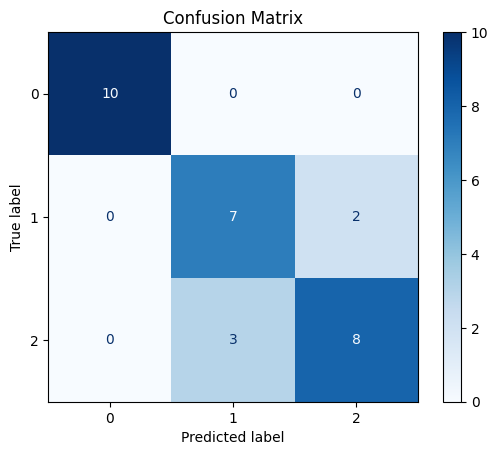

In [71]:
# Vẽ confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [72]:
# In classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.70      0.78      0.74         9
           2       0.80      0.73      0.76        11

    accuracy                           0.83        30
   macro avg       0.83      0.84      0.83        30
weighted avg       0.84      0.83      0.83        30



In [73]:
# Sinh 20 mẫu dữ liệu ngẫu nhiên với các giá trị đặc trưng thuộc đoạn [-1,1]
X_new_samples = np.random.uniform(low=-1, high=1, size=(20, X_scaled.shape[1]))
y_new_samples = np.random.randint(low=0, high=len(np.unique(y)), size=20)

print("Generated 20 new random samples (X_new_samples):\n", X_new_samples)
print("\nCorresponding random labels (y_new_samples):\n", y_new_samples)

Generated 20 new random samples (X_new_samples):
 [[ 0.69576917  0.49764808  0.60421198  0.65606241]
 [-0.15641813  0.95563187 -0.94672906  0.29305476]
 [ 0.50940968 -0.62149667 -0.31445921  0.4485343 ]
 [-0.16326589 -0.81170827 -0.90890064 -0.35226741]
 [ 0.8812183  -0.33331073 -0.67221762  0.29485706]
 [-0.15591438 -0.25372971  0.20163625 -0.4210961 ]
 [ 0.08043428 -0.09948055  0.23152691 -0.84526866]
 [ 0.91819656  0.12089467 -0.70329977 -0.51795129]
 [-0.0737057  -0.39121728  0.62031306  0.75758363]
 [-0.28190442  0.99570192  0.93579069  0.98985464]
 [-0.21166878  0.7667348   0.34176258 -0.87510619]
 [ 0.88983363  0.01488512  0.27498729  0.2923392 ]
 [-0.59165732  0.45443697  0.91432808  0.86464787]
 [ 0.33405961 -0.20307421 -0.89815639  0.30974248]
 [ 0.09419362 -0.41594562 -0.47413202 -0.1011737 ]
 [ 0.06676572  0.01942765  0.53764658  0.4954841 ]
 [-0.4715115   0.75958279  0.91217665  0.98887922]
 [-0.90402818 -0.47416161  0.96201814  0.71961546]
 [ 0.24062114  0.72237304 -0.221

In [79]:
# Phân loại 20 mẫu dữ liệu trên
y_new_pred = model.predict(X_new)
print("Predicted labels for new data points (y_new_pred):")
print(y_new_pred)

Predicted labels for new data points (y_new_pred):
[1 0 0 0 2 1 1 1 1 1 2 0 0 1 0 1 0 0 0 0]


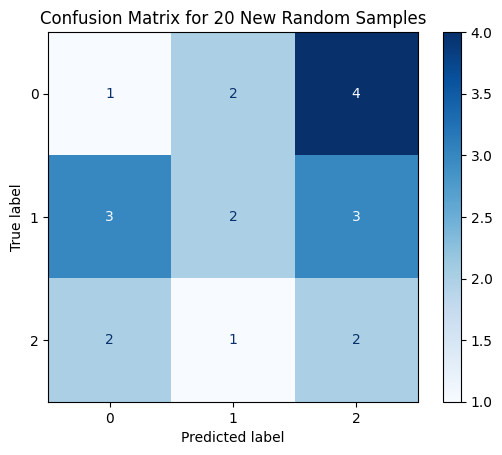

In [80]:
# Phân loại 20 mẫu dữ liệu ngẫu nhiên mới (chỉ sử dụng 2 đặc trưng đầu tiên cho phù hợp với model)
y_new_samples_pred = model.predict(X_new_samples[:, :2])

# Vẽ confusion matrix cho kết quả phân loại 20 mẫu dữ liệu trên
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_new_samples = confusion_matrix(y_new_samples, y_new_samples_pred)
disp_new_samples = ConfusionMatrixDisplay(confusion_matrix=cm_new_samples, display_labels=model.classes_)
disp_new_samples.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for 20 New Random Samples')
plt.show()

In [81]:
# In giá trị của hàm phân loại khi áp dụng SVM cho 20 điểm dữ liệu trên
decision_values_new_samples = model.decision_function(X_new_samples[:, :2])
print("Giá trị của hàm phân loại cho 20 điểm dữ liệu ngẫu nhiên mới:")
print(decision_values_new_samples)

Giá trị của hàm phân loại cho 20 điểm dữ liệu ngẫu nhiên mới:
[[-0.2641996   0.98124063  2.26504422]
 [ 2.24681782 -0.22743417  0.86214425]
 [-0.29230215  1.25715501  2.26313134]
 [-0.26680163  2.25907101  1.11425851]
 [-0.29682397  1.2439441   2.28125869]
 [-0.21731577  2.21046591  1.04602081]
 [-0.24139863  2.19411108  1.18395755]
 [-0.28928941  1.18880646  2.28010072]
 [-0.24745375  2.22956258  1.13363627]
 [ 2.26284345 -0.23435534  0.80784626]
 [ 2.23620569 -0.20439887  0.84717693]
 [-0.29070544  1.20629666  2.27953251]
 [ 2.25741729  0.84514401 -0.23872142]
 [-0.27255535  1.21883586  2.24004548]
 [-0.265865    2.23571061  1.20137677]
 [-0.22521372  1.16705413  2.1729493 ]
 [ 2.26521887  0.78772977 -0.22718766]
 [ 2.20287596  1.21706288 -0.25795253]
 [ 0.91645975 -0.1754579   2.19704567]
 [-0.278278    1.23549326  2.24194891]]


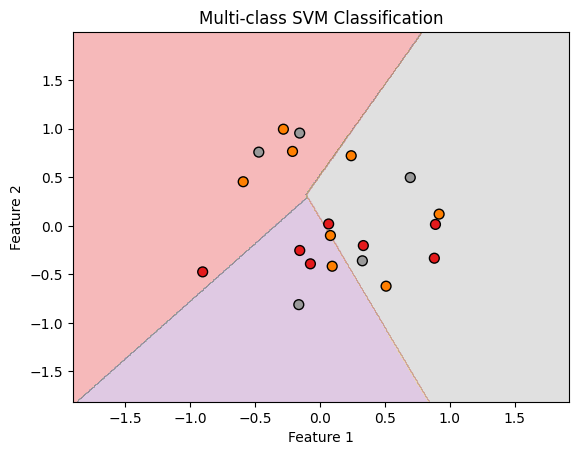

In [82]:
# Vẽ 20 điểm dữ liệu trên và siêu phẳng phân lớp
X_new_samples_2d = X_new_samples[:, :2]
plot_svm_multi(X_new_samples_2d, y_new_samples, model)